# Derivatives Pricing — Enhanced Walkthrough

**Module 5 — Enhanced notebook**

This notebook provides more explanation and visuals for the pricing routines in `05_derivatives_pricing`. Each section shows the numeric outputs, interpretation, and at least one visual aid to help interpret the numbers.


In [14]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
sys.path.append(os.path.abspath('..'))
from derivatives_pricing import (
    OptionParams, BlackScholesPricer, BinomialTreePricer, MonteCarloPricer,
    VasicekModel, CIRModel, black_76_price, forward_price, put_call_parity
)


## Black–Scholes: Price, Greeks and Intuition

Compute price and Greeks, show a bar chart for sensitivities, and explain how to interpret each Greek in practice.


In [15]:
params = OptionParams(spot=100, strike=100, maturity=1.0, rate=0.05, volatility=0.2, dividend_yield=0.01, option_type='call')
bs = BlackScholesPricer(params)
price = bs.price()
greeks = bs.greeks()
summary = pd.DataFrame([{ 'price': price, **greeks }])
print('Black–Scholes summary:')
display(summary.T.style.format('{:.6f}'))


Black–Scholes summary:


,0
price,9.826298
delta,0.611763
gamma,0.018880
vega,37.759294
theta,-5.731667
rho,51.350012


### Visualizing Price & Delta vs Spot
Plot how price and delta change with spot — this demonstrates moneyness effects and why delta approaches 0/1 in deep OTM/ITM regimes.


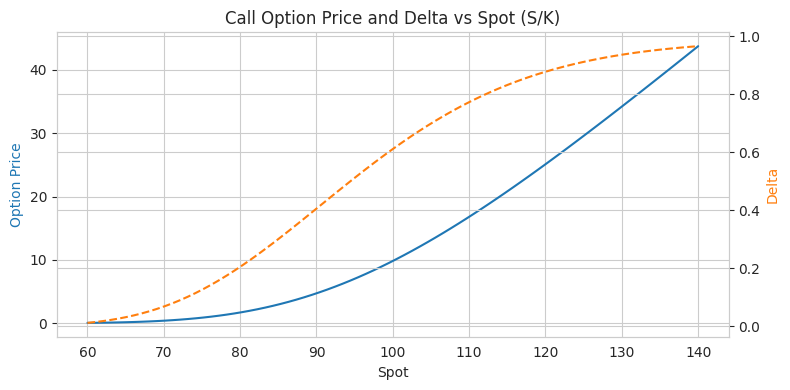

In [16]:
spots = np.linspace(60, 140, 80)
prices = []
deltas = []
for s in spots:
    p = OptionParams(spot=float(s), strike=100, maturity=1.0, rate=0.05, volatility=0.2, dividend_yield=0.01, option_type='call')
    pr = BlackScholesPricer(p)
    prices.append(pr.price())
    deltas.append(pr.greeks()['delta'])

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(spots, prices, color='tab:blue', label='Price')
ax1.set_xlabel('Spot')
ax1.set_ylabel('Option Price', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(spots, deltas, color='tab:orange', linestyle='--', label='Delta')
ax2.set_ylabel('Delta', color='tab:orange')
ax1.set_title('Call Option Price and Delta vs Spot (S/K)')
ax1.grid(True)
fig.tight_layout()
plt.show()


### Greeks bar chart and interpretation
Show the scalar Greeks so readers can quickly see the relative magnitudes and decide hedging priorities.


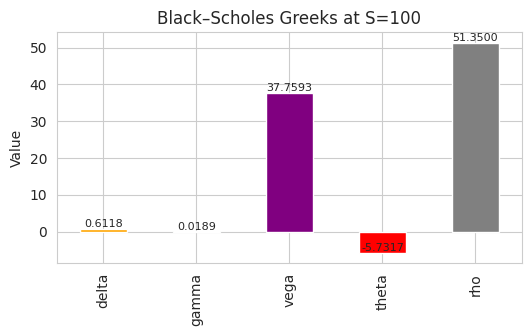

In [17]:
g = pd.Series(greeks)
ax = g.plot(kind='bar', figsize=(6,3), color=['orange','green','purple','red','gray'])
ax.set_ylabel('Value')
ax.set_title('Black–Scholes Greeks at S=100')
for i,p in enumerate(ax.patches):
    ax.annotate(f"{p.get_height():.4f}", (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.show()


## Implied Volatility
Compute implied vol from a market price and visualize where it sits on the price-vs-volatility curve.


Market price: 10.317613, Implied vol: 0.2130


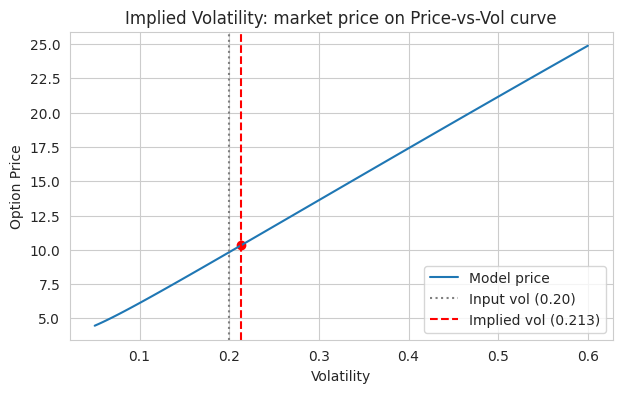

In [18]:
market_price = price * 1.05  # market trades 5% above model price
implied_vol = BlackScholesPricer.implied_volatility(market_price, params)
print(f'Market price: {market_price:.6f}, Implied vol: {implied_vol:.4f}')
vols = np.linspace(0.05, 0.6, 120)
vol_prices = [BlackScholesPricer(OptionParams(spot=100, strike=100, maturity=1.0, rate=0.05, volatility=v, dividend_yield=0.01, option_type='call')).price() for v in vols]
plt.figure(figsize=(7,4))
plt.plot(vols, vol_prices, label='Model price')
plt.axvline(params.volatility, color='gray', linestyle=':', label='Input vol (0.20)')
plt.axvline(implied_vol, color='red', linestyle='--', label=f'Implied vol ({implied_vol:.3f})')
plt.scatter([implied_vol], [market_price], color='red')
plt.xlabel('Volatility')
plt.ylabel('Option Price')
plt.title('Implied Volatility: market price on Price-vs-Vol curve')
plt.legend()
plt.show()


## Put-Call Parity Check
Verify parity numerically and explain the residual. Large residuals indicate arbitrage or inconsistent inputs.


In [19]:
call_price = BlackScholesPricer(params).price()
put_params = OptionParams(spot=100, strike=100, maturity=1.0, rate=0.05, volatility=0.2, dividend_yield=0.01, option_type='put')
put_price = BlackScholesPricer(put_params).price()
residual = put_call_parity(params, call_price, put_price)
print('Call price: {:.6f}, Put price: {:.6f}, Parity residual (C - P - (S e^{{-qT}} - K e^{{-rT}})): {:.6e}'.format(call_price, put_price, residual))
if abs(residual) < 1e-8:
    print('Parity holds (within numerical precision).')
else:
    print('Parity residual non-zero: check inputs or market mispricing.')

Call price: 9.826298, Put price: 5.944257, Parity residual (C - P - (S e^{-qT} - K e^{-rT})): 0.000000e+00
Parity holds (within numerical precision).


## Binomial Tree: Convergence and Early Exercise Value
Compare European vs American put, show convergence plot, and explain why American > European for puts with non-zero dividends/rates.


In [20]:
params_put = OptionParams(spot=50, strike=55, maturity=0.5, rate=0.03, volatility=0.25, dividend_yield=0.0, option_type='put')
steps = [25, 50, 100, 200, 400]
rows = []
for n in steps:
    euro = BinomialTreePricer(params_put, steps=n, is_american=False).price()
    amer = BinomialTreePricer(params_put, steps=n, is_american=True).price()
    rows.append({'steps': n, 'european_put': euro, 'american_put': amer})
binom_df = pd.DataFrame(rows)
display(binom_df.style.format('{:.6f}'))


,steps,european_put,american_put
0,25.000000,6.128347,6.290192
1,50.000000,6.123270,6.286083
2,100.000000,6.135190,6.294701
3,200.000000,6.130838,6.290692
4,400.000000,6.132005,6.291442


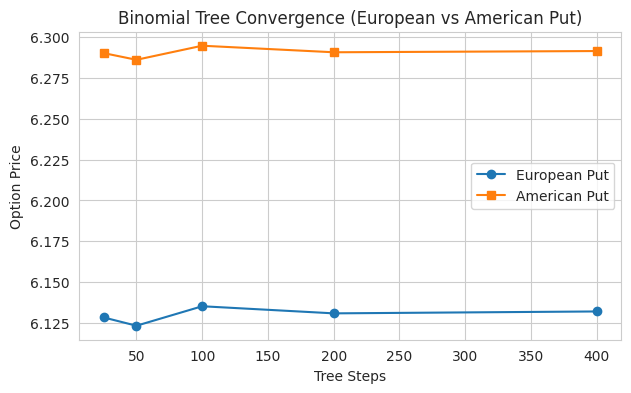

Note: American put >= European put because early exercise can capture higher immediate payoff when beneficial.


In [21]:
plt.figure(figsize=(7,4))
plt.plot(binom_df['steps'], binom_df['european_put'], marker='o', label='European Put')
plt.plot(binom_df['steps'], binom_df['american_put'], marker='s', label='American Put')
plt.xlabel('Tree Steps')
plt.ylabel('Option Price')
plt.title('Binomial Tree Convergence (European vs American Put)')
plt.legend()
plt.show()
print('Note: American put >= European put because early exercise can capture higher immediate payoff when beneficial.')


## Monte Carlo: Convergence and Payoff Distribution
Show convergence with confidence bands and histogram of terminal prices and payoffs to build intuition about risk and payoff skew.


In [22]:
mc_params = OptionParams(spot=100, strike=95, maturity=1.0, rate=0.04, volatility=0.2, dividend_yield=0.01, option_type='call')
bs_price = BlackScholesPricer(mc_params).price()
paths = [2000, 5000, 10000, 20000, 40000]
records = []
for n in paths:
    mc = MonteCarloPricer(mc_params, n_paths=n, n_steps=1, seed=42)
    price_mc, stderr = mc.price()
    records.append({'paths': n, 'mc_price': price_mc, 'stderr': stderr})
mc_df = pd.DataFrame(records)
display(mc_df.style.format({'mc_price': '{:.6f}', 'stderr': '{:.6f}'}))


,paths,mc_price,stderr
0,2000,11.880455,0.343443
1,5000,12.064526,0.220809
2,10000,12.018682,0.154857
3,20000,12.093927,0.110281
4,40000,12.094986,0.077687


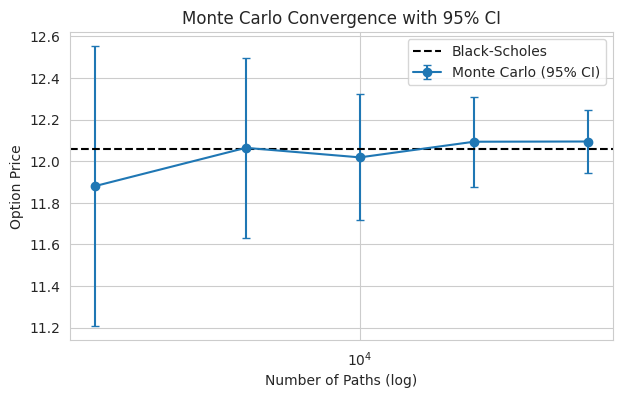

In [23]:
plt.figure(figsize=(7,4))
plt.errorbar(mc_df['paths'], mc_df['mc_price'], yerr=1.96*mc_df['stderr'], marker='o', capsize=3, label='Monte Carlo (95% CI)')
plt.axhline(bs_price, color='black', linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.xlabel('Number of Paths (log)')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence with 95% CI')
plt.legend()
plt.show()


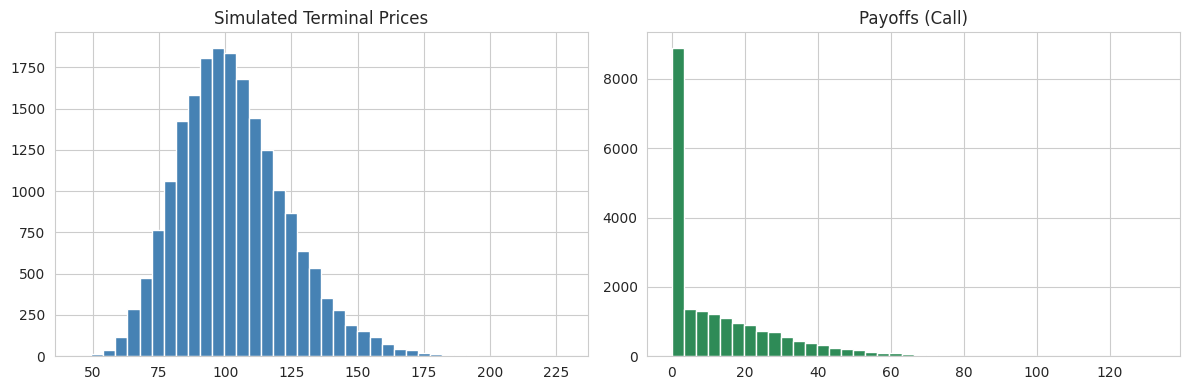

In [24]:
# Histogram of terminal prices and payoffs
mc = MonteCarloPricer(mc_params, n_paths=20000, n_steps=1, seed=7)
terminal = mc._simulate_terminal()
payoffs = np.maximum(terminal - mc_params.strike, 0.0)
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(terminal, bins=40, color='steelblue')
axes[0].set_title('Simulated Terminal Prices')
axes[1].hist(payoffs, bins=40, color='seagreen')
axes[1].set_title('Payoffs (Call)')
plt.tight_layout()
plt.show()


## Black-76: Options on Forwards — Sensitivity to Forward Price
Plot Black‑76 price as forward varies; useful when calibrating models for futures/options desks.


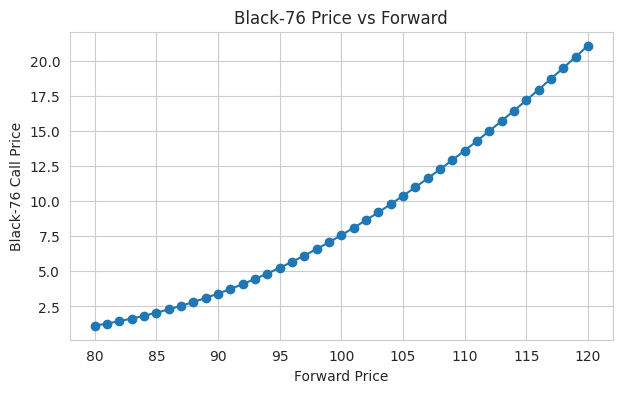

In [25]:
fwd_grid = np.linspace(80, 120, 41)
black76_prices = [black_76_price(forward=f, strike=100, maturity=1.0, rate=0.05, volatility=0.2, option_type='call') for f in fwd_grid]
plt.figure(figsize=(7,4))
plt.plot(fwd_grid, black76_prices, marker='o')
plt.xlabel('Forward Price')
plt.ylabel('Black-76 Call Price')
plt.title('Black-76 Price vs Forward')
plt.grid(True)
plt.show()


## Term Structure: Vasicek vs CIR — Table and Plot
Compute zero-coupon prices and yields, present a formatted table, and plot the yield curves with annotations.


In [26]:
maturities = np.array([0.5,1,2,3,5,7,10])
vasicek = VasicekModel(a=0.5, b=0.03, sigma=0.01, r0=0.02)
cir = CIRModel(a=0.6, b=0.04, sigma=0.08, r0=0.03)
vasicek_prices = np.array([vasicek.zero_coupon_bond_price(t) for t in maturities])
cir_prices = np.array([cir.zero_coupon_bond_price(t) for t in maturities])
vasicek_yields = -np.log(vasicek_prices)/maturities
cir_yields = -np.log(cir_prices)/maturities
term_df = pd.DataFrame({'maturity': maturities, 'vasicek_price': vasicek_prices, 'cir_price': cir_prices, 'vasicek_yield': vasicek_yields, 'cir_yield': cir_yields})
display(term_df.style.format({'vasicek_price':'{:.6f}','cir_price':'{:.6f}','vasicek_yield':'{:.4f}','cir_yield':'{:.4f}'}))


,maturity,vasicek_price,cir_price,vasicek_yield,cir_yield
0,0.500000,0.989481,0.984445,0.0211,0.0314
1,1.000000,0.978124,0.968063,0.0221,0.0325
2,2.000000,0.953810,0.934047,0.0236,0.0341
3,3.000000,0.928399,0.899622,0.0248,0.0353
4,5.000000,0.877062,0.832496,0.0262,0.0367
5,7.000000,0.827141,0.769426,0.0271,0.0374
6,10.000000,0.756745,0.683259,0.0279,0.0381


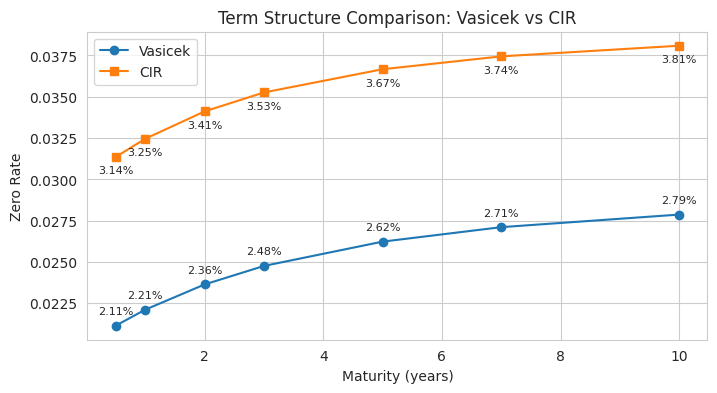

In [27]:
plt.figure(figsize=(8,4))
plt.plot(maturities, vasicek_yields, marker='o', label='Vasicek')
plt.plot(maturities, cir_yields, marker='s', label='CIR')
plt.xlabel('Maturity (years)')
plt.ylabel('Zero Rate')
plt.title('Term Structure Comparison: Vasicek vs CIR')
for t,y in zip(maturities, vasicek_yields):
    plt.annotate(f'{y:.2%}', (t,y), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
for t,y in zip(maturities, cir_yields):
    plt.annotate(f'{y:.2%}', (t,y), textcoords='offset points', xytext=(0,-12), ha='center', fontsize=8)
plt.legend()
plt.grid(True)
plt.show()


---
This enhanced notebook is intended to be more instructive: each numeric output is followed by a visualization and a short interpretation to help non-specialist reviewers understand the results at a glance.
